<a href="https://colab.research.google.com/github/hye-lily/in-summer/blob/main/%EC%9D%98%EB%AF%B8%EB%B6%84%ED%8F%AC%EC%99%80_%ED%95%B4%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 코퍼스로 본 한국어 의미: 분포에서 해석까지
## Colab 실습 노트북

- **2교시**: Kiwi로 한국어 코퍼스 처리 — 빈도, KWIC, 연어 추출
- **3교시**: 두 가지 의미 현상 분석 — '잡다'의 다의성, '결국'의 의미 운율

**사용 도구**: Google Colab · kiwipiepy · pandas · matplotlib

> 이 노트북은 시연용 샘플 텍스트를 내장하고 있어, 모두의 말뭉치 접근 없이도 즉시 실행됩니다. 실제 분석 시에는 모두의 말뭉치 또는 본인 코퍼스로 교체하세요.

> 또한 제이슨 규모가 너무 클 경우 제이슨 파일 1개만 가지고 실습하시기 바랍니다.
---

## 1. 환경 설치

Colab은 매 세션마다 환경이 초기화됩니다. 아래 셀을 한 번 실행하세요.

In [ ]:
# Kiwi 한국어 형태소 분석기 설치
!pip install -q kiwipiepy pandas matplotlib

# 설치 확인
import kiwipiepy, pandas, matplotlib
print(f"kiwipiepy {kiwipiepy.__version__}")
print(f"pandas    {pandas.__version__}")
print("환경 준비 완료.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 19.2 MB/s eta 0:00:00
kiwipiepy 0.23.1
pandas    2.2.2
환경 준비 완료.


### 한글 폰트 설정 (시각화용)

Colab 기본 환경에는 한글 폰트가 없어 그래프에서 □□□로 깨집니다. 아래 셀을 실행해 폰트를 설치하세요.

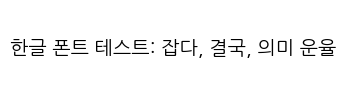

In [ ]:
# 한글 폰트 설치 및 matplotlib 등록
!apt-get install -qq -y fonts-nanum > /dev/null
!fc-cache -fv > /dev/null

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

# 나눔고딕 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 테스트
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트: 잡다, 결국, 의미 운율',
        ha='center', va='center', fontsize=14)
ax.axis('off')
plt.show()

## 📂 2. 샘플 코퍼스 로드

공유 폴더에 업로드된 **신문 말뭉치 JSON 파일 2개**를 사용합니다.  
본격적인 분석에 앞서 다음 두 단계를 거칩니다.

| 단계 | 작업 | 목적 |
|:---:|:---|:---|
| **① 구조 진단** | 첫 파일의 JSON 계층 확인 | 키 구조 파악 (`document → paragraph → form`) |
| **② 병합·추출** | 세 파일 → 문장 리스트 `texts` | 이후 분석의 공통 입력 데이터 생성 |

> 💡 **Tip.** 모두의 말뭉치는 표준 포맷을 따르지만 배포본에 따라 키가 달라질 수 있으니,  
> 코드를 그대로 돌리기 전에 ①단계 진단 결과를 꼭 확인하세요.

---

In [ ]:
import json, glob
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

CORPUS_DIR = '/content/drive/MyDrive/'

# 📌 Google Drive에서 파일을 복사하면 '.json의 사본' 형태로 저장될 수 있으므로
#    '*.json*' 패턴으로 두 경우 모두 탐지
json_files = sorted(glob.glob(f'{CORPUS_DIR}NWRW1900000058.json*') + glob.glob(f'{CORPUS_DIR}NWRW1900000059.json*'))

print(f'📂 발견된 JSON 파일: {len(json_files)}개')
for f in json_files:
    size_mb = Path(f).stat().st_size / (1024 * 1024)
    print(f'   - {Path(f).name} ({size_mb:.2f} MB)')

# Initialize texts as an empty list
texts = []

if len(json_files) == 0:
    print("\n⚠️ 경고: 지정된 경로에서 JSON 파일을 찾을 수 없습니다.")
    print("      노트북에 내장된 샘플 텍스트로 대체하여 진행합니다.")
    # Provide a simple hardcoded sample for `texts` to allow the rest of the notebook to run
    texts = [
        "그는 마음을 다잡고 시험장에 들어갔다.",
        "수많은 노력 끝에 결국 목표를 달성했다.",
        "어부들은 밤새도록 그물에 물고기를 잡았다.",
        "드디어 긴 기다림 끝에 새로운 프로젝트가 시작되었다.",
        "결국 그녀는 회사를 그만두기로 결정했다.",
        "나는 균형을 잡기 위해 애썼지만 결국 넘어지고 말았다.",
        "잡다한 생각들로 머릿속이 복잡했다.",
        "그는 기회를 잡기 위해 최선을 다했다.",
        "마침내 우리는 해가 뜨는 것을 보았다.",
        "오랜 시간 끝에 결국 진실이 밝혀졌다."
    ]
    print(f"샘플 텍스트 {len(texts)}개 로드 완료.")
else:
    print('\n' + '='*60)
    print('🔍 첫 번째 파일의 구조 진단')
    print('='*60)

    # 첫 파일의 JSON 계층 구조 점검
    with open(json_files[0], encoding='utf-8') as f:
        sample = json.load(f)

    # [1] 최상위 키
    print(f'\n[1] 최상위 키: {list(sample.keys())}')

    # [2] 메타정보
    if 'metadata' in sample:
        print(f'\n[2] 메타정보:')
        for k, v in sample['metadata'].items():
            print(f'   {k}: {v}')

    # [3] document 레벨 확인
    if 'document' in sample:
        docs = sample['document']
        print(f'\n[3] document 개수: {len(docs):,}')
        print(f'    document[0]의 키: {list(docs[0].keys())}')

        # [4]~[5] paragraph 레벨 확인
        if 'paragraph' in docs[0]:
            paras = docs[0]['paragraph']
            print(f'\n[4] 첫 document의 paragraph 개수: {len(paras)}')
            print(f'    paragraph[0]의 키: {list(paras[0].keys())}')
            print(f'\n[5] 샘플 텍스트 (paragraph[0]["form"]):')
            print(f'    "{paras[0].get("form", "")[:150]}..."')

    # ── 2-(2). 병합 및 문장 추출 ─────────────────────────
    print('\n' + '='*60)
    print('🧩 모든 JSON 파일 병합 및 문장 추출')
    print('='*60)

    all_sentences = []
    file_stats = []
    for file_path in json_files:
        before = len(all_sentences)
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            if 'document' in data:
                for doc in data['document']:
                    if 'paragraph' in doc:
                        for para in doc['paragraph']:
                            form = para.get('form', '').strip()
                            if form:                # 빈 문자열 제외
                                all_sentences.append(form)
        added = len(all_sentences) - before
        file_stats.append((Path(file_path).name, added))
        print(f'   ✓ {Path(file_path).name}: {added:,} 문장 추출')

    texts = all_sentences

    print(f'\n✅ 총 {len(texts):,}개의 문장을 추출했습니다.')
    print('\n📝 샘플 5문장:')
    for i, s in enumerate(texts[:5], 1):
        print(f'   [{i}] {s[:100]}{"..." if len(s) > 100 else ""}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📂 발견된 JSON 파일: 2개
   - NWRW1900000058.json의 사본 (50.33 MB)
   - NWRW1900000059.json의 사본 (94.81 MB)

🔍 첫 번째 파일의 구조 진단

[1] 최상위 키: ['id', 'metadata', 'document']

[2] 메타정보:
   title: 국립국어원 신문 말뭉치 NWRW1900000058
   creator: 국립국어원
   distributor: 국립국어원
   year: 2019
   category: 신문 > 전국 종합지
   annotation_level: ['원시']
   sampling: 부분 추출 - 임의 추출

[3] document 개수: 10,454
    document[0]의 키: ['id', 'metadata', 'paragraph']

[4] 첫 document의 paragraph 개수: 7
    paragraph[0]의 키: ['id', 'form']

[5] 샘플 텍스트 (paragraph[0]["form"]):
    "김부겸 선거사무소 바로 옆에 사무실 낸 김문수…..."

🧩 모든 JSON 파일 병합 및 문장 추출
   ✓ NWRW1900000058.json의 사본: 112,432 문장 추출
   ✓ NWRW1900000059.json의 사본: 214,562 문장 추출

✅ 총 326,994개의 문장을 추출했습니다.

📝 샘플 5문장:
   [1] 김부겸 선거사무소 바로 옆에 사무실 낸 김문수…
   [2] 새누리당 김문수(65) 전 경기도지사와 더불어민주당의 김부겸(58) 전 의원이 서로 마주보고 있는 빌딩에 각각 선거사무소를 열고 본격적인 선거 운동에 들어갔다. 이들은 4월13일 ...

## 3. Kiwi로 형태소 분석하기

Kiwi의 핵심은 `kiwi.tokenize(text)`입니다. 각 토큰은 `Token(form, tag, start, len)` 형태로 반환됩니다.

**주요 품사 태그**:
- `NNG` 일반명사, `NNP` 고유명사
- `VV` 동사, `VA` 형용사
- `MAG` 일반부사
- `JKO` 목적격조사 (을/를) — 직접 목적어 식별에 유용

In [ ]:
from kiwipiepy import Kiwi

kiwi = Kiwi()

# 한 문장 분석 예시
sample = "그는 마음을 다잡고 시험장에 들어갔다."
tokens = kiwi.tokenize(sample)

print(f"입력: {sample}\n")
print(f"{'형태':<10}{'품사':<8}{'시작':<6}{'길이'}")
print("-" * 36)
for t in tokens:
    print(f"{t.form:<10}{t.tag:<8}{t.start:<6}{t.len}")

입력: 그는 마음을 다잡고 시험장에 들어갔다.

형태        품사      시작    길이
------------------------------------
그         NP      0     1
는         JX      1     1
마음        NNG     3     2
을         JKO     5     1
다잡        VV-R    7     2
고         EC      9     1
시험장       NNG     11    3
에         JKB     14    1
들어가       VV      16    3
었         EP      18    1
다         EF      19    1
.         SF      20    1


## 4. 빈도 분석 — 형태소 단위로

어절 빈도가 아닌 **형태소 단위 빈도**를 보면, 조사·어미를 분리한 의미 단위 빈도가 드러납니다. 이후 분석 대상이 되는 '잡다', '결국', '마침내', '드디어'가 충분한 빈도로 등장하는지 먼저 확인합니다.

> ⏱️ **소요 시간 안내**  
> 아래 형태소 분석 셀은 코퍼스 규모에 따라 **10~20분** 정도 걸릴 수 있습니다. 셀 좌측 `[*]` 표시가 깜빡이며 진행 바가 움직이는 동안은 정상입니다.  
> **10분 이상 걸린다면** 분석을 중지(■)하고, 위의 코퍼스 로드 셀(2번)에서 사용할 JSON 파일 수를 줄이거나 샘플링한 후 다시 실행하세요.
>
> 💡 형태소 분석은 **한 번만** 수행하고, 이후 KWIC·공기 분석·측도 계산은 모두 그 결과(`tokenized`)를 재사용합니다.

In [ ]:
from collections import Counter
import pandas as pd
from tqdm.auto import tqdm   # 진행 바
import time

# 전체 코퍼스를 형태소 분석 — 한 번만!
# 이후 KWIC, 공기 분석, 측도 계산은 모두 이 결과(tokenized)를 재사용합니다.
print(f"분석 대상 문장 수: {len(texts):,}")
print("형태소 분석 시작...\n")

start = time.time()
tokenized = []   # 문장별 토큰 리스트 (KWIC, 공기 분석에서 재사용)

for text in tqdm(texts, desc="Kiwi 분석"):
    tokenized.append(kiwi.tokenize(text))

elapsed = time.time() - start
print(f"\n✅ 완료: {elapsed:.1f}초 ({elapsed/60:.1f}분)\n")

# 평탄화 — 전체 통계용
all_tokens = [t for toks in tokenized for t in toks]
print(f"전체 형태소 수: {len(all_tokens):,}")

# 품사별 빈도
pos_counter = Counter(t.tag for t in all_tokens)
print(f"\n품사별 분포 (상위 10):")
for tag, n in pos_counter.most_common(10):
    print(f"  {tag:<6} {n:,}")

분석 대상 문장 수: 326,994
형태소 분석 시작...



Kiwi 분석:   0%|          | 0/326994 [00:00<?, ?it/s]


✅ 완료: 1153.9초 (19.2분)

전체 형태소 수: 21,592,849

품사별 분포 (상위 10):
  NNG    6,214,325
  VV     1,060,369
  EC     1,028,869
  ETM    1,010,883
  NNP    970,569
  JKB    871,389
  NNB    844,329
  JX     734,831
  EF     718,648
  JKO    716,995


In [ ]:
# 품사별 어형 빈도 — 명사, 동사, 형용사, 부사
def freq_by_pos(tokens, target_tags):
    counter = Counter()
    for t in tokens:
        if t.tag in target_tags:
            counter[t.form] += 1
    return counter

noun_freq = freq_by_pos(all_tokens, {'NNG', 'NNP'})
verb_freq = freq_by_pos(all_tokens, {'VV'})
adj_freq  = freq_by_pos(all_tokens, {'VA'})
adv_freq  = freq_by_pos(all_tokens, {'MAG'})

# 표로 보기
def top_df(counter, n=15, label='형태'):
    return pd.DataFrame(counter.most_common(n), columns=[label, '빈도'])

print("=== 명사 상위 15 ===")
print(top_df(noun_freq).to_string(index=False))
print("\n=== 동사 상위 15 ===")
print(top_df(verb_freq).to_string(index=False))
print("\n=== 부사 상위 15 ===")
print(top_df(adv_freq).to_string(index=False))

=== 명사 상위 15 ===
 형태    빈도
  말 43094
대통령 40660
 정부 30563
  때 23545
 대표 22346
  뒤 21092
 한국 20518
 미국 19340
 조사 19023
 의원 18795
 문제 18498
  박 16651
  면 15758
 사회 15218
 관련 15141

=== 동사 상위 15 ===
형태    빈도
 하 86794
 되 43284
대하 37492
 있 29495
위하 28282
밝히 25627
 보 25299
지나 21180
보이 18421
나오 18140
통하 14086
따르 13245
만들 13219
 내 11984
열리 10411

=== 부사 상위 15 ===
형태    빈도
 더 15609
 또 12587
함께 12240
가장  9523
 안  9267
 못  9077
모두  8469
 및  7629
다시  6770
 잘  6305
현재  5661
특히  5272
없이  5209
직접  5082
많이  4391


**관찰 포인트**: '잡다'와 '결국'이 각각 동사/부사 빈도 상위에 위치하는지 확인하세요. 분석 대상 어휘가 충분한 빈도를 가져야 후속 분석이 의미 있습니다.* 상위에 없다...

## 5. KWIC (Key Word In Context)

검색어를 중심으로 좌우 문맥을 정렬해 보여주는 방식입니다. 같은 단어의 여러 용법을 한눈에 비교하기에 가장 직관적인 도구입니다.

여기서는 **형태소 분석 결과를 기반**으로 KWIC을 만듭니다. 어형이 달라도 기본형이 같으면 매칭되도록(예: '잡았다', '잡으려', '잡고' → 모두 '잡다'로 매칭) 구현합니다.

In [ ]:
def make_kwic(tokenized, lemma, target_tag, window=5):
    """
    형태소 단위 KWIC 생성. 미리 분석된 tokenized를 재사용 (재분석 X).
    - lemma: 검색할 기본형 (예: '잡', '결국')
    - target_tag: 품사 태그 — 문자열 또는 튜플
                  (예: 'VV' 또는 ('MAG', 'NNG'))
                  Kiwi는 VV-R/VV-I 같은 변이 태그를 만들기도 하므로
                  startswith로 비교합니다.
    - window: 좌우 형태소 개수
    """
    if isinstance(target_tag, str):
        target_tag = (target_tag,)

    rows = []
    for sent_idx, toks in enumerate(tokenized):
        forms = [t.form for t in toks]
        for i, t in enumerate(toks):
            tag_match = any(t.tag.startswith(tt) for tt in target_tag)
            if t.form == lemma and tag_match:
                left  = ' '.join(forms[max(0, i-window):i])
                right = ' '.join(forms[i+1:i+1+window])
                rows.append({
                    '문장번호': sent_idx,
                    '좌측 문맥': left,
                    '검색어': t.form,
                    '품사': t.tag,
                    '우측 문맥': right,
                })
    return pd.DataFrame(rows)

# '잡다' KWIC — 'VV'로 시작하는 모든 태그
kwic_jab = make_kwic(tokenized, '잡', 'VV', window=4)
print(f"'잡다' 용례 수: {len(kwic_jab)}")
kwic_jab.head(15)

'잡다' 용례 수: 4089


,문장번호,좌측 문맥,검색어,품사,우측 문맥
0,427,목표 를 낮추 어,잡,VV-R,었 다 . 지나
1,467,걸리 는 것 으로,잡,VV-R,고 있 다 .
2,510,이 라는 닭 을,잡,VV-R,는 데 꺼내 어
3,510,들 ᆫ ‘ 소,잡,VV-R,는 칼 ’ 격
4,533,선거 운동 곳곳 서,잡,VV-R,음
5,661,개성 사이 에 자리,잡,VV-R,은 개성공단 이 활성
6,662,진지 등 이 자리,잡,VV-R,고 있 었 다
7,662,공격 축선 에 자리,잡,VV-R,으면서 북한군 처지 에서
8,697,중국 과 손 을,잡,VV-R,고 사드 배치 에
9,787,접근 으로 가닥 을,잡,VV-R,어 가 는 것


**학생 활동 (워크시트 6-1, 6-2)**: 위 KWIC을 보고 '잡다'의 의미를 몇 가지로 분류할 수 있는지 살펴보세요. 좌측 문맥(특히 직접목적어)에 따라 의미가 어떻게 갈리는지 관찰하는 것이 핵심입니다.

In [ ]:
# '결국' KWIC — Kiwi가 MAG 또는 NNG로 태깅하므로 둘 다 허용
kwic_gyeolguk = make_kwic(tokenized, '결국', ('MAG', 'NNG'), window=5)
print(f"'결국' 용례 수: {len(kwic_gyeolguk)}")
kwic_gyeolguk.head(15)

'결국' 용례 수: 2999


,문장번호,좌측 문맥,검색어,품사,우측 문맥
0,38,차 가 워낙 크 어서,결국,MAG,합의 를 이루 지 못
1,52,합의 가 안 되 ᆫ다면,결국,MAG,소송 으로 가 ᆯ 수
2,52,수 밖에 없 습니다 .,결국,NNG,최 회장 이 이혼 의
3,299,하 ᆫ 병원 치료 로,결국,NNG,그 의 부모 는 암
4,300,모든 것 이 다 .,결국,NNG,나 는 꿈 을 이루
5,383,"이 계속 되 면서 ,",결국,MAG,정두언 위원장 은 국방위 산
6,496,의 추억 지키 기 는,결국,NNG,이루 기 어렵 은 꿈
7,555,이성 적 판단 보다 는,결국,NNG,은 감성 적 선호도 가
8,696,하 며 사드 배치 가,결국,MAG,중국 을 겨냥 하 ᆫ
9,788,갈등 으로 확대 되 더니,결국,NNG,미 - 중 담판 으로


**관찰 포인트**: '결국' 우측 문맥에 등장하는 술어들의 평가적 색채를 살펴보세요. 부정 술어가 우세하다면 의미 운율의 흔적이 보이기 시작합니다.

## 6. 케이스 A — '잡다'의 다의성 분석

워크시트 6번과 직접 연결됩니다. '잡다'의 좌측 문맥에서 **직접 목적어 명사**를 추출해 공기 분포를 살펴봅니다.

In [ ]:
def extract_object_of(tokenized, verb_lemma, window_left=4):
    """
    동사의 좌측 문맥에서 목적격조사(JKO)와 결합한 명사를 추출.
    미리 분석된 tokenized를 재사용 (재분석 X).
    """
    obj_counter = Counter()
    examples = {}
    for toks in tokenized:
        for i, t in enumerate(toks):
            if t.form == verb_lemma and t.tag.startswith('VV'):
                # 좌측에서 가장 가까운 JKO + 그 앞 명사
                for j in range(i-1, max(-1, i-window_left-1), -1):
                    if toks[j].tag == 'JKO':
                        if j > 0 and toks[j-1].tag.startswith('NN'):
                            noun = toks[j-1].form
                            obj_counter[noun] += 1
                            examples.setdefault(noun, [])
                            if len(examples[noun]) < 2:
                                examples[noun].append(
                                    ' '.join(tk.form for tk in toks)
                                )
                        break
    return obj_counter, examples

obj_counter, obj_examples = extract_object_of(tokenized, '잡')

# 명사 자체 빈도 (이후 측도 계산에서 재사용)
noun_freq = Counter(t.form for t in all_tokens if t.tag.startswith('NN'))

print(f"'잡다'의 좌측 목적어 명사 — 상위 20")
print("-" * 60)
for noun, cnt in obj_counter.most_common(20):
    ex = obj_examples[noun][0] if noun in obj_examples else ''
    print(f"  {noun:<8} {cnt:>4}  | 예: {ex[:50]}")

'잡다'의 좌측 목적어 명사 — 상위 20
------------------------------------------------------------
  손         204  | 예: 러시아 도 중국 과 손 을 잡 고 사드 배치 에 반대 하 는 움직임 을 보이 고 있 다 .
  자리        128  | 예: 의원 들 의 상임위 배정 권한 은 국회 의장 에게 있 지만 , 원내 교섭 단체 는 의석 비
  발목        116  | 예: 그러나 한 새누리당 의원 은 “ 서 의원 의 욕심 탓 에 협상 이 꼬이 었 던 것 아니 냐
  중심         69  | 예: 이 같 은 분위기 반전 의 중심 에 ᆫ 대표 팀 의 맏 언니 이 자 주장 이 ᆫ 임영희 (
  방향         62  | 예: 골대 안 을 꽉 채우 ᆫ 듯 하 ᆫ 노이어 는 이탈리아 선수 두 명 이 슈팅 을 골문 밖 
  일정         61  | 예: 서울 강남경찰서 는 16 일 한 여성 이 ‘ 박 씨 에게 성폭행 을 당하 었 다 ’ 며 박
  가닥         60  | 예: 기습 적 이 ᆫ 4 차 북핵 실험 에서 촉발 되 ᆫ 한반도 위기 가 미국 과 중국 의 극 
  정권         54  | 예: 하나 는 지구 정반대 편 에서 오 었 다 . 브라질 의회 가 지우마 호세프 대통령 의 탄핵
  마이크        46  | 예: 8 일 오전 국회 의원 회관 . 서청원 새누리당 의원 이 같 은 당 원유철 의원 이 주도 
  기회         44  | 예: 반면 세계 1 위 리디아 고 는 17 번 홀 ( 파 3 · 181 야드 ) 에서 티 샷 으
  포즈         37  | 예: 중국 의 쑨양 이 금메달 을 깨물 며 포즈 를 잡 고 있 다 . 자유 형 남자 200 ｍ 
  균형         33  | 예: 트레버 단편 의 주인공 들 은 삶 의 고 빗길 에서 돌부리 에 발 이 걸리 어 비틀거리 거
  토끼         32  | 예: 검찰 부패 범죄 특별 수사단 (

### 6-1. 의미 군집 직접 만들어 보기

워크시트 6-2 활동에 해당합니다. 위에서 추출된 명사들을 **본인이 의미 부류로 직접 분류**해 보세요. 아래는 분석 결과를 정리하기 위한 작업 셀입니다.

In [ ]:
# 학생이 직접 채울 부분 — 의미 군집 분류
my_clusters = {
    '기준설정':     ['날짜', '예약', '균형', '방향'],
    '동물도살':     [ '물고기', '멧돼지'],
    '관계위치':     ['손', '마음', '키', '발판'],
    '장소점유':     ['자리', '터'],
    '문제해결':     ['범인', '도둑','트집', '꼬투리'],

}

# 군집별 빈도 합계
print("=== 내가 만든 의미 군집별 빈도 ===\n")
for cluster, words in my_clusters.items():
    total = sum(obj_counter.get(w, 0) for w in words)
    word_breakdown = ', '.join(f'{w}({obj_counter.get(w,0)})' for w in words if obj_counter.get(w,0) > 0)
    print(f"[{cluster}] 합계 {total}")
    print(f"   {word_breakdown}\n")

=== 내가 만든 의미 군집별 빈도 ===

[기준설정] 합계 104
   날짜(8), 예약(1), 균형(33), 방향(62)

[동물도살] 합계 20
   물고기(14), 멧돼지(6)

[관계위치] 합계 211
   손(204), 마음(3), 키(4)

[장소점유] 합계 153
   자리(128), 터(25)

[문제해결] 합계 29
   범인(10), 도둑(1), 트집(12), 꼬투리(6)



**토의 (워크시트 6-3)**: '자리'는 위 분류에서 두 군집('기회 확보'와 '안착')에 모두 들어갔습니다. KWIC을 다시 보고, 어느 쪽 의미가 더 우세한지, 둘이 정말 다른 의미인지 따져 보세요.

### 6-2. 의미 군집 시각화

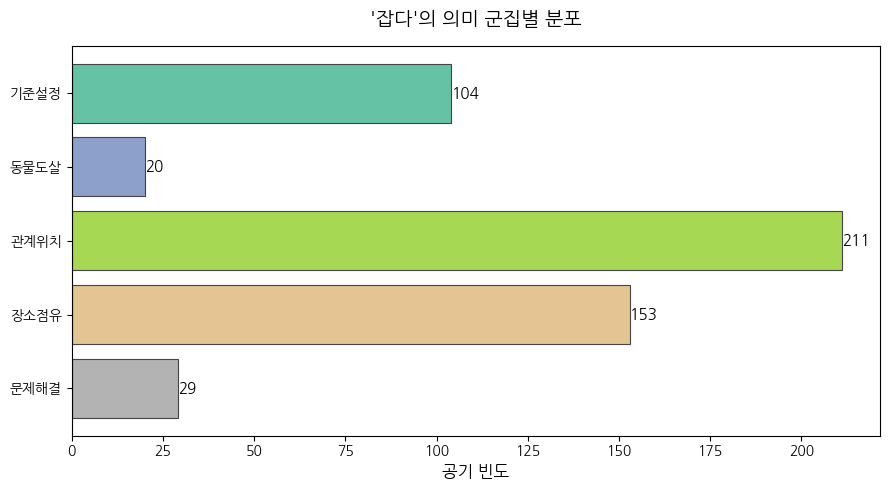

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cluster_totals = {c: sum(obj_counter.get(w, 0) for w in ws) for c, ws in my_clusters.items()}

fig, ax = plt.subplots(figsize=(9, 5))
clusters = list(cluster_totals.keys())
totals = list(cluster_totals.values())
colors = plt.cm.Set2(np.linspace(0, 1, len(clusters)))

bars = ax.barh(clusters, totals, color=colors, edgecolor='#444', linewidth=0.8)
ax.set_xlabel('공기 빈도', fontsize=12)
ax.set_title("'잡다'의 의미 군집별 분포", fontsize=14, pad=15)
ax.invert_yaxis()

for bar, val in zip(bars, totals):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=11)

plt.tight_layout()
plt.show()

## 7. 케이스 B — '결국 / 마침내 / 드디어'의 의미 운율

워크시트 7번과 직접 연결됩니다. 세 부사의 우측 문맥에서 **핵심 술어(VV/VA)**를 추출하고, 평가적 색채(긍정/부정/중립)별로 분류합니다.

여기서는 시연을 위해 **소형 감성 사전**을 직접 만들어 사용합니다. 실제 연구에서는 KOSAC, KNU 한국어 감성사전 등을 활용하세요.

In [ ]:
def extract_predicate_after(tokenized, adv_lemma, window_right=10,
                            adv_tags=('MAG', 'NNG')):
    """
    부사의 우측 문맥에서 가장 가까운 술어 추출.
    미리 분석된 tokenized를 재사용 (재분석 X).

    주의: Kiwi는 '결국'을 문맥에 따라 MAG(부사)로도, NNG(명사)로도
    태깅합니다. 따라서 두 태그를 모두 허용해야 실제 부사 용례를
    놓치지 않습니다. VV-R, VV-I 같은 불규칙 활용 세부 태그도 포함시킵니다.
    """
    predicates = []
    for toks in tokenized:
        for i, t in enumerate(toks):
            if t.form == adv_lemma and t.tag in adv_tags:
                # 우측 window 안에서 가장 가까운 술어
                for j in range(i + 1, min(len(toks), i + window_right + 1)):
                    # VV, VA, VV-R, VV-I, VA-R, VA-I 모두 포함
                    if toks[j].tag.startswith('VV') or toks[j].tag.startswith('VA'):
                        predicates.append(toks[j].form)
                        break
    return predicates

# 세 부사의 우측 술어 추출 — 루프로 분리 표시
target_advs = ['결국', '마침내', '드디어']
preds = {}

for adv in target_advs:
    ps = extract_predicate_after(tokenized, adv)
    preds[adv] = ps
    print(f"\n[{adv}] 추출된 우측 술어 (n={len(ps)})")
    print("-" * 50)
    # 빈도 상위 10개만 미리 보기
    top = Counter(ps).most_common(10)
    for pred, cnt in top:
        print(f"  {pred:<10} {cnt}")


[결국] 추출된 우측 술어 (n=1786)
--------------------------------------------------
  하          78
  되          77
  받          47
  있          43
  이어지        36
  지나         34
  없          32
  가          29
  위하         28
  대하         26

[마침내] 추출된 우측 술어 (n=144)
--------------------------------------------------
  하          8
  되          6
  받          6
  찾          4
  돌아오        4
  열리         3
  오르         3
  서          3
  꺾          3
  나오         3

[드디어] 추출된 우측 술어 (n=73)
--------------------------------------------------
  되          4
  나오         3
  열리         3
  오          3
  불타오르       2
  들어서        2
  타          2
  많          2
  만나         2
  드러내        2


In [ ]:
# 시연용 미니 감성 사전
# Kiwi가 동사 어간을 분리해 주므로 (예: '났다' → '나/VV' + '었/EP' + '다/EF'),
# 사전 키도 어간 형태로 작성합니다.
sentiment_lex = {
    # 부정
    '나':       'NEG',  # 병이 나다 (이 코퍼스에서)
    '실패하':   'NEG',
    '죽':       'NEG',
    '닫':       'NEG',
    '폐기되':   'NEG',
    '이혼하':   'NEG',
    '악화되':   'NEG',
    '탈락하':   'NEG',
    '끊어지':   'NEG',
    '무산되':   'NEG',
    '마르':     'NEG',  # 말라 죽다
    '끝나':     'NEG',  # 실패로 끝나다 (맥락의존적이지만 본 코퍼스에서는 NEG)
    # 긍정
    '합격하':   'POS',
    '찾':       'POS',
    '화해하':   'POS',
    '이루':     'POS',
    '성공하':   'POS',
    '우승하':   'POS',
    # 중립
    '도착하':   'NEU',
    '오':       'NEU',
    '깨닫':     'NEU',
    '나오':     'NEU',
    '그치':     'NEU',
    '시작되':   'NEU',
    '끝':       'NEU',  # 공사가 끝나다 같은 일반 종결
}

def classify(pred, lex=sentiment_lex):
    # 정확히 일치 우선
    if pred in lex:
        return lex[pred]
    # 그 다음 어간 시작 일치 (활용형 흡수)
    for stem, polarity in lex.items():
        if pred.startswith(stem):
            return polarity
    return 'UNK'

# 부사별 polarity 분포
rows = []
for adv, ps in preds.items():
    for p in ps:
        rows.append({'부사': adv, '술어': p, '극성': classify(p)})
df_pred = pd.DataFrame(rows)
print(df_pred)

       부사  술어   극성
0      결국  이루  POS
1      결국   가  UNK
2      결국  굽히  UNK
3      결국  이기  UNK
4      결국  이루  POS
...   ...  ..  ...
1998  드디어   보  UNK
1999  드디어   갚  UNK
2000  드디어   되  UNK
2001  드디어   내  UNK
2002  드디어  나오  NEU

[2003 rows x 3 columns]


### 7-2. 분포 결과 기록 (워크시트 7-2)

부사별로 우측 술어의 극성 분포를 교차표로 정리합니다. 표본 크기 N과 각 극성 비율을 워크시트에 기록하세요.

In [ ]:
# 부사 × 극성 교차표
ctab = pd.crosstab(df_pred['부사'], df_pred['극성'])
ctab_pct = ctab.div(ctab.sum(axis=1), axis=0) * 100

print("=== 빈도 ===")
print(ctab)
print("\n=== 비율 (%) ===")
print(ctab_pct.round(1))

=== 빈도 ===
극성   NEG  NEU  POS   UNK
부사                      
결국    54   47   23  1662
드디어    1    9    2    61
마침내    4    7   10   123

=== 비율 (%) ===
극성   NEG   NEU  POS   UNK
부사                       
결국   3.0   2.6  1.3  93.1
드디어  1.4  12.3  2.7  83.6
마침내  2.8   4.9  6.9  85.4


**시각화**: 누적 막대그래프로 세 부사의 극성 분포를 한눈에 비교합니다.

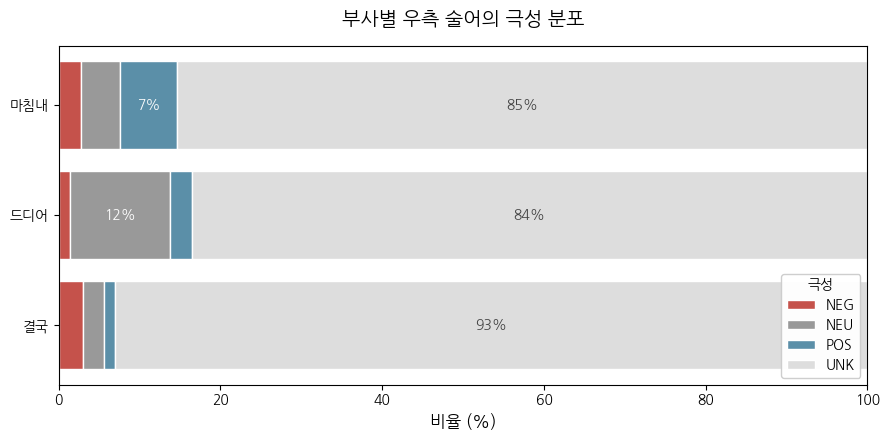

In [ ]:
# 누적 막대로 비교
fig, ax = plt.subplots(figsize=(9, 4.5))
ctab_pct = ctab_pct.reindex(columns=['NEG', 'NEU', 'POS', 'UNK'], fill_value=0)

color_map = {'NEG': '#C5524B', 'NEU': '#999999', 'POS': '#5B8FA8', 'UNK': '#DDDDDD'}
bottom = np.zeros(len(ctab_pct))

for col in ctab_pct.columns:
    vals = ctab_pct[col].values
    ax.barh(ctab_pct.index, vals, left=bottom,
            label=col, color=color_map.get(col, '#888'),
            edgecolor='white', linewidth=1)
    # 막대 안에 % 표시
    for i, v in enumerate(vals):
        if v > 5:
            ax.text(bottom[i] + v/2, i, f'{v:.0f}%',
                    va='center', ha='center', fontsize=10,
                    color='white' if col != 'UNK' else '#444')
    bottom += vals

ax.set_xlabel('비율 (%)', fontsize=12)
ax.set_title("부사별 우측 술어의 극성 분포", fontsize=14, pad=15)
ax.legend(title='극성', loc='lower right', framealpha=0.95)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

### 7-3. 연관성 측도 비교 (워크시트 7-3)

세 부사 각각에 대해 **MI, t-score, log-likelihood, Dice** 네 가지 측도로 우측 술어와의 결합 강도를 계산합니다.
각 측도는 같은 공기 데이터를 다르게 보여줍니다 — 어느 측도가 어떤 패턴을 강조하는지 직접 비교해 보세요.

In [ ]:
import math
from collections import Counter

# ── 측도 4개 정의 ─────────────────────────────────────
def mutual_information(co_occ, freq_a, freq_b, total):
    """
    MI = log2( P(A,B) / (P(A) * P(B)) )
       = log2( (co_occ * total) / (freq_a * freq_b) )
    """
    if co_occ == 0 or freq_a == 0 or freq_b == 0:
        return float('-inf')
    return math.log2((co_occ * total) / (freq_a * freq_b))

def t_score(co_occ, freq_a, freq_b, total):
    """t-score = (co_occ - expected) / sqrt(co_occ)"""
    if co_occ == 0:
        return 0
    expected = (freq_a * freq_b) / total
    return (co_occ - expected) / math.sqrt(co_occ)

def log_likelihood(co_occ, freq_a, freq_b, total):
    """
    Dunning's G² (log-likelihood ratio).
    2x2 분할표 기반.
    """
    a = co_occ                       # A와 B 모두 출현
    b = freq_a - co_occ              # A만 출현
    c = freq_b - co_occ              # B만 출현
    d = total - freq_a - freq_b + co_occ  # 둘 다 비출현
    if a <= 0 or b < 0 or c < 0 or d <= 0:
        return 0.0

    def _safe_log(x):
        return math.log(x) if x > 0 else 0.0

    row1, row2 = a + b, c + d
    col1, col2 = a + c, b + d
    n = total

    e_a = row1 * col1 / n
    e_b = row1 * col2 / n
    e_c = row2 * col1 / n
    e_d = row2 * col2 / n

    g2 = 2 * (
        a * _safe_log(a / e_a) +
        b * _safe_log(b / e_b) if b > 0 else 0 +
        c * _safe_log(c / e_c) if c > 0 else 0 +
        d * _safe_log(d / e_d)
    )
    return g2

def dice(co_occ, freq_a, freq_b, total=None):
    """Dice = 2 * co_occ / (freq_a + freq_b)"""
    if freq_a + freq_b == 0:
        return 0.0
    return 2 * co_occ / (freq_a + freq_b)

# ── 부사별 측도 계산 ─────────────────────────────────
# 전체 토큰에서 술어 빈도(VV/VA) 집계 — 마지널 빈도용
predicate_freq = Counter()
for t in all_tokens:
    if t.tag.startswith('VV') or t.tag.startswith('VA'):
        predicate_freq[t.form] += 1

total_tokens = len(all_tokens)

def build_assoc_table(adv, predicate_list, top_n=10):
    """부사 1개에 대해 측도 4개로 정렬한 표 반환"""
    co_counter = Counter(predicate_list)
    freq_adv = len(predicate_list)  # 해당 부사의 우측 술어 추출 횟수 (근사)

    rows = []
    for pred, co in co_counter.items():
        freq_pred = max(predicate_freq.get(pred, 0), co)
        rows.append({
            '술어': pred,
            '공기빈도': co,
            '술어빈도': freq_pred,
            'MI':  round(mutual_information(co, freq_adv, freq_pred, total_tokens), 2),
            't-score': round(t_score(co, freq_adv, freq_pred, total_tokens), 2),
            'log-likelihood': round(log_likelihood(co, freq_adv, freq_pred, total_tokens), 2),
            'Dice': round(dice(co, freq_adv, freq_pred), 4),
        })
    return pd.DataFrame(rows)

# 부사별로 측도 4개 모두 계산하고 측도별 상위 정렬 출력
for adv in target_advs:
    df = build_assoc_table(adv, preds[adv])
    if df.empty:
        print(f"\n[{adv}] — 추출된 술어 없음")
        continue

    print(f"\n{'='*70}")
    print(f"[{adv}] 측도별 상위 5개")
    print('='*70)
    for measure in ['MI', 't-score', 'log-likelihood', 'Dice']:
        print(f"\n── {measure} 기준 상위 5 ──")
        print(df.sort_values(measure, ascending=False).head(5).to_string(index=False))


[결국] 측도별 상위 5개

── MI 기준 상위 5 ──
  술어  공기빈도  술어빈도    MI  t-score  log-likelihood   Dice
 빠져들     1     4 11.56      1.0           14.03 0.0011
약삭빠르     1     5 11.24      1.0           13.58 0.0011
 죽어나     1     6 10.98      1.0           13.22 0.0011
  마렵     1     6 10.98      1.0           13.22 0.0011
때려치우     1     7 10.75      1.0           12.91 0.0011

── t-score 기준 상위 5 ──
 술어  공기빈도  술어빈도   MI  t-score  log-likelihood   Dice
  되    77 43285 4.43     8.37          328.76 0.0034
  하    78 86796 3.44     8.02          233.36 0.0018
  받    47 28457 4.32     6.51          193.28 0.0031
이어지    36  4466 6.61     5.94          259.17 0.0115
 지나    34 21180 4.28     5.53          137.76 0.0030

── log-likelihood 기준 상위 5 ──
 술어  공기빈도  술어빈도   MI  t-score  log-likelihood   Dice
  되    77 43285 4.43     8.37          328.76 0.0034
이어지    36  4466 6.61     5.94          259.17 0.0115
  하    78 86796 3.44     8.02          233.36 0.0018
  받    47 28457 4.32     6.51          193.28 0.0031


**측도 비교 활동 (워크시트 7-3 채우기)**:

각 부사별로 위 출력에서 측도별 상위 5개를 워크시트 표에 옮겨 적으세요. 그리고 다음을 관찰하세요:

- **MI**: 저빈도이지만 강하게 결합되는 술어를 위로 올립니다 (예: 한두 번만 같이 나와도 둘 다 희귀하면 MI는 큼). → 특이하고 의미 있는 결합 발견에 유용.
- **t-score**: 고빈도 일반 결합을 위로 올립니다. → 안정적이고 흔한 패턴 확인에 유용.
- **log-likelihood (G²)**: 빈도와 통계적 유의성을 균형 있게 반영합니다. → 코퍼스 크기 변화에 가장 견고.
- **Dice**: 두 단어 공기의 상대적 비율로, 빈도 효과를 정규화합니다. → 0~1 범위라 직관적 해석 가능.

세 부사를 비교했을 때, **'결국'이 부정 술어와 결합하는 강도**는 어느 측도에서 가장 두드러지나요? 그 차이가 의미 운율 가설을 뒷받침하나요?

**해석 활동 (워크시트 7-4)**:

1. '결국'은 '마침내', '드디어'와 비교했을 때 어느 극성에 치우쳐 있나요?
2. 이 차이가 사전적 정의로 설명될 수 있나요? 표준국어대사전에서 세 부사를 찾아 비교해 보세요.
3. 코퍼스가 작아 통계적 유의성은 검증하기 어렵습니다. 실제 연구에서 어떤 추가 분석이 필요할까요? (카이제곱? 효과크기? 더 큰 코퍼스?)

> 다음 셀(7-3)에서는 이 분포를 **연관성 측도** 관점에서 다시 들여다봅니다.